# Day 2: Machine Learning and Neural Networks!

In this exercise file, we will go over more advanced ML practice with the same MNIST data. We will create and evaluate some basic visual model architectures.

## Ex 1: Loading the MNIST Data

Run the follwing code box to get the same data we used in Day 1 and load using PyTorch's `DataLoader` abstraction.

In [1]:
import torch
import torch.nn as nn
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# Load MNIST data
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

print("Train batches: ", len(train_loader))
print("Test batches: ", len(test_loader))

Train batches:  938
Test batches:  157


## Ex 2a: Building a Neural Network - Multi-Layer Perceptron (MLP)

The first machine learning model we will build is a Multi-Layer Perceptron. 

Our hand-made MLP class will be a subclass of the `nn.Module` so it will have to call the `super().__init__()` function. We will be writing code for the layers with `nn.Sequential`.

Hint #1: Neuron layers are constructed in two steps. First, we create them as linear neurons and then we apply their activation function onto them. 

_v = w1 * x1 + ...  + wn * xn + b_ and then _y = f(v)_ - we do not need to create the linear layer by hand, see `nn.Linear()`

Hint #2: What shape does input data X have (throwback to Day 1)? This will decide our first step that "reshapes" the tensor array to a mathematically usable structure. Then we will apply our linear and activation functions a few times!



In [2]:
# MLP model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            # TODO being with the reshaping layer
            nn.Flatten(),
            # TODO now our first linear layer and remember that 28 x 28 = 784; let's do hidden dimensions = 256
            nn.Linear(784,256), #f(input_size,output_size)
            # TODO activation function
            nn.ReLU(),
            # TODO our next linear layer, remember input dimensions = 256; let's do output dimensions = 128
            nn.Linear(256,128),
            # TODO activation function
            nn.ReLU(),
            # TODO our final linear layer, remember input dimensions = 128; our output are 10 classes
            nn.Linear(128,10)
        )

    def forward(self, x):
        return self.network(x)

Now let's instantiate the MLP object and see what PyTorch stores for us.

In [3]:
mlp = MLP()

# Let's see what printing the model class does:
print(mlp)

# As well as the parameters:
print("Total parameters: ", sum(p.numel() for p in mlp.parameters()))

MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters:  235146


## Ex 2b: Training and Evaluating a Neural Network (MLP)

Now we will learn to train and test data using our model.

To train, for every batch of input data we need to:
1. clear the gradients of the model's parameters (hint: `zero_grad()`),
2. input the data into the model,
3. evaluate our loss,
4. trigger backpropagation (hint: `backward()`),
5. update our total loss,
6. take one step with our optimizer;
* we also need to keep track of the correct predictions in the batch and update this var.

In [4]:
# Training function
def train_epoch(model, loader, optimizer, criterion):
    model.train()       # putting the model in training mode
    total_loss, correct = 0, 0
    for images, labels in loader:
        # TODO training step #1
        optimizer.zero_grad()
        # TODO training step #2
        outputs=model(images)
        # TODO training step #3
        loss=criterion(outputs,labels)
        # TODO training step #4
        loss.backward()
        # TODO training step #6
        optimizer.step()
        # TODO training step #5
        total_loss+=loss.item()
        # TODO calculeaza acuratetea modelului
        correct += (outputs.argmax(1)==labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

To evaluate, we no longer need to keep track of gradients (why we use `torch.no_grad()`). For every batch of data, we now need to:
1. input the data into the model, 
2. update the total loss (similar to training), 
3. keep track of the correct predictions (same as training).

In [10]:
# Testing function
def evaluate(model, loader, criterion):
    model.eval()       # putting the model in evaluating mode
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            # TODO evaluating step #1
            outputs=model(images)
            # TODO evaluating step #2
            total_loss+=criterion(outputs,labels).item()
            # TODO evaluating step #3
            correct += (outputs.argmax(1)==labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

With these two functions now implemented, let's run it with pretty output using the code box below.

In [12]:
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3) #1e-3=10^(-3)*1=0.001
criterion = nn.CrossEntropyLoss() #functia de loss; logaritm de ex

# Calling the training and evaluating functions
print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)
for epoch in range(10):
    tr_loss, tr_acc = train_epoch(mlp, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(mlp, test_loader, criterion)
    print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {val_loss:>8.4f}  {val_acc:>7.4f}")

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
    1      0.0170     0.9943    0.0876   0.9785
    2      0.0146     0.9949    0.0693   0.9817
    3      0.0138     0.9955    0.0904   0.9785
    4      0.0100     0.9966    0.0883   0.9808
    5      0.0123     0.9957    0.0936   0.9769
    6      0.0098     0.9966    0.0980   0.9795
    7      0.0099     0.9966    0.1078   0.9786
    8      0.0104     0.9966    0.0952   0.9797
    9      0.0055     0.9978    0.1093   0.9792
   10      0.0093     0.9969    0.1046   0.9808


## Ex 3a: Making our own Convolutional Neural Network (CNN)

Why CNNs? The MLP flattened the image and thus throwing away spatial structure.

CNNs on the other hand use local filters that slide across the image, preserving position. This is named convolution, and we will try it below before implementing it into a model.

In [ ]:
# plotting library inport
import matplotlib.pyplot as plt

# TODO store the a training image as a tensor shaped [1, 1, 28, 28] --> your choice of index
sample_img = train_data[3][0].unsqueeze(0) #unsqueeze: 1x28x28->1x1x28x28 

# manual edge-detection filter
edge_filter = torch.tensor([
    [-1., -1., -1.],
    [-1.,  8., -1.],
    [-1., -1., -1.]
]).reshape(1, 1, 3, 3)

# Make sure you understand this conv2d line before moving on
conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False) #bias=false->nu tb sa urci sau sa cobori kernelul
conv.weight.data = edge_filter

with torch.no_grad():
    filtered = conv(sample_img)

Now let's plot this:

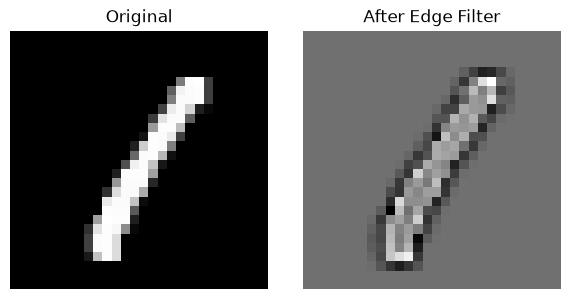

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(sample_img.squeeze(), cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(filtered.squeeze().detach(), cmap='gray')
axes[1].set_title("After Edge Filter")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

### The Main Event - Convolutional Neural Network (CNN)

We will have two `nn.Sequential()` objects working together: think of them as an artist and a detective. The artist (`features`) will be the eyes help us identify what visual structures are, while the detective (`classifier`) will be the brain that will interpret logically how these pieces of information fit together.  

In [20]:
# CNN model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # TODO convolutional layer with input 1, output 32, kernel 3, padding 1; transforms [B,1,28,28] to [B,32,28,28]
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            # TODO activation function
            nn.ReLU(),
            # TODO max pooling layer with kernel 2; transforms to [B,32,14,14]
            nn.MaxPool2d(2),

            # TODO convolutional layer with input 32, output 64, kernel 3, padding 1; transforms to [B,64,14,14]
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            # TODO activation function
            nn.ReLU(),
            # TODO max pooling layer with kernel 2; transforms to [B,64,7,7]
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            # TODO reshaping layer, just like for MLP
            nn.Flatten(),
            # TODO linear layer with inputs 64*7*7, outputs 128
            nn.Linear(64*7*7,128),
            # TODO activation function
            nn.ReLU(),
            # TODO a dropout of 50%
            nn.Dropout(0.5),
            # TODO linear layer with inputs 128, outputs 10 (no. of out classes!)
            nn.Linear(128,10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

Now let's instantiate our CNN and see what PyTorch stores for us.

In [21]:
cnn = CNN()

print(cnn)
print("CNN parameters: ", sum(p.numel() for p in cnn.parameters()))
print("MLP parameters: ", sum(p.numel() for p in mlp.parameters()))
print("CNN has fewer parameters but uses spatial structure (expect better accuracy!)")

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
CNN parameters:  421642
MLP parameters:  235146
CNN has fewer parameters but uses spatial structure (expect better accuracy!)


Compared to the MLP, we will only change the optimizer (`Adam` this time), we can train and evalutate with the same exact functions we wrote before! Run the code below to see.

In [22]:
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

# Train the CNN (same loop, different model)
print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)
for epoch in range(5):
    tr_loss, tr_acc = train_epoch(cnn, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(cnn, test_loader, criterion)
    print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {val_loss:>8.4f}  {val_acc:>7.4f}")

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
    1      0.2553     0.9206    0.0546   0.9812
    2      0.0923     0.9721    0.0381   0.9870
    3      0.0709     0.9789    0.0348   0.9884
    4      0.0583     0.9821    0.0299   0.9899
    5      0.0500     0.9852    0.0309   0.9893


## Ex 3b: Confusion Matrix

Now let's check our evaluation metrics per-class using a confusion matrix.

In [24]:
# some imports for our confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

all_preds, all_labels = [], []
cnn.eval()      # putting the model in evaluation mode
with torch.no_grad():
    for images, labels in test_loader:
        all_preds.extend(cnn(images).argmax(1).numpy())
        all_labels.extend(labels.numpy())

Let's graph it now (it's just a plot, don't worry).

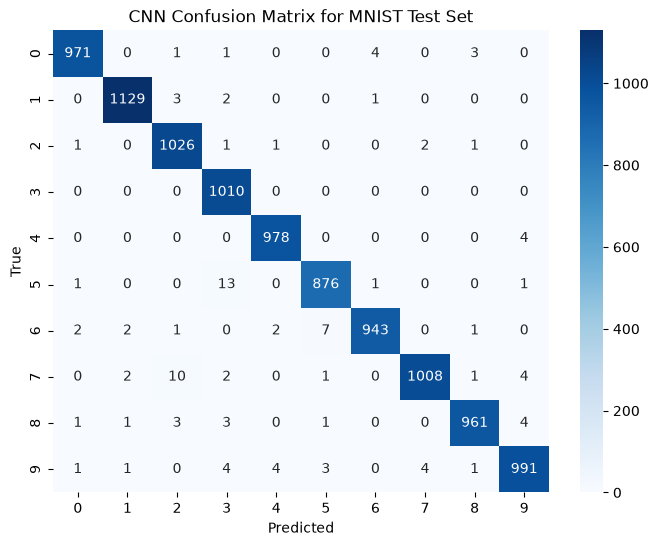

In [25]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix for MNIST Test Set")
plt.show()

Congratulations on finishing Day 2 of ML!